# Eigenvalue distribution of the updated plate matrix $A$

This notebook computes **all** eigenvalues of the symmetric matrix in `system_updated_plate/A.npz`, plots their distribution, and counts exact numerical duplicates and tolerance-based clusters of nearby eigenvalues.

The matrix is sparse, but obtaining the complete spectrum requires a dense symmetric eigensolve. On a typical workstation this cell can take several minutes and needs roughly 4--8 GB of working memory.

In [1]:
from pathlib import Path
import os
import tempfile
from time import perf_counter

# Keep Matplotlib's cache outside the repository.
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "cg_hyperbox_matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.linalg import eigvalsh
from scipy.sparse import load_npz

DATA_DIR = Path("system_updated_plate")
A = load_npz(DATA_DIR / "A.npz").tocsr()
A.eliminate_zeros()

symmetry_defect = A - A.T
max_symmetry_defect = (
    float(np.max(np.abs(symmetry_defect.data))) if symmetry_defect.nnz else 0.0
)
print(f"shape: {A.shape}")
print(f"nonzeros: {A.nnz:,}")
print(f"density: {A.nnz / np.prod(A.shape):.6e}")
print(f"maximum symmetry defect: {max_symmetry_defect:.3e}")
if A.shape[0] != A.shape[1] or max_symmetry_defect != 0.0:
    raise ValueError("A must be square and exactly symmetric.")

shape: (21570, 21570)
nonzeros: 659,988
density: 1.418521e-03
maximum symmetry defect: 0.000e+00


## Complete symmetric eigensolve

`eigvalsh` exploits symmetry and returns the eigenvalues in ascending order. Only the eigenvalues, not eigenvectors, are requested. The sparse matrix is converted directly to Fortran-contiguous dense storage so the LAPACK driver can overwrite it and limit avoidable copies.

In [2]:
started = perf_counter()
A_dense = A.toarray(order="F")
eigenvalues = eigvalsh(
    A_dense, lower=True, overwrite_a=True, check_finite=False, driver="evr"
)
del A_dense
elapsed = perf_counter() - started

spectral_span = float(eigenvalues[-1] - eigenvalues[0])
spectral_scale = max(float(np.max(np.abs(eigenvalues))), spectral_span, 1.0)
summary = pd.Series({
    "number of eigenvalues": eigenvalues.size,
    "smallest eigenvalue": eigenvalues[0],
    "largest eigenvalue": eigenvalues[-1],
    "spectral span": spectral_span,
    "condition number (lambda_max/lambda_min)": eigenvalues[-1] / eigenvalues[0],
    "eigensolve time (seconds)": elapsed,
})
display(summary.to_frame("value"))

,value
number of eigenvalues,2.157000e+04
smallest eigenvalue,1.803999e-03
largest eigenvalue,1.032440e+04
spectral span,1.032440e+04
condition number (lambda_max/lambda_min),5.723065e+06
eigensolve time (seconds),3.934553e+02


## Distribution plots

The linear histogram shows where most eigenvalues lie on the original scale. The empirical cumulative distribution (ECDF) makes the full range readable on a logarithmic eigenvalue axis. The final panel shows adjacent gaps normalized by the spectral scale; small gaps indicate nearly repeated eigenvalues.

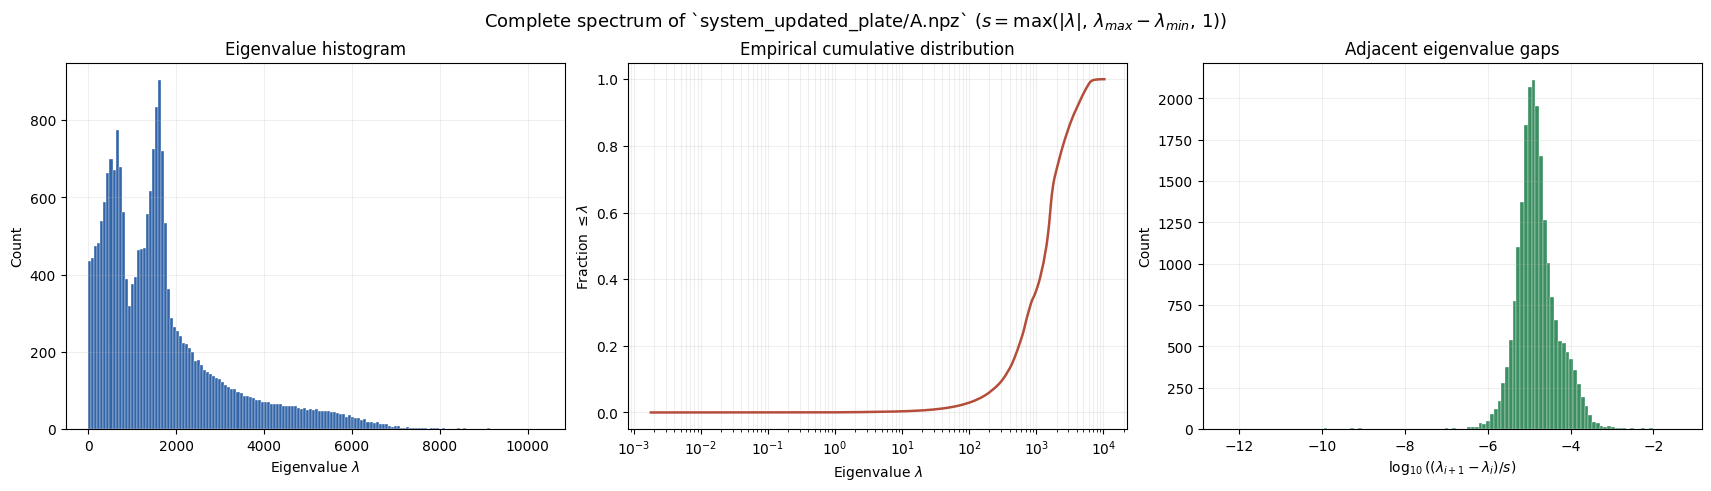

In [3]:
gaps = np.diff(eigenvalues)
normalized_gaps = gaps / spectral_scale
positive_normalized_gaps = normalized_gaps[normalized_gaps > 0]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

axes[0].hist(eigenvalues, bins=150, color="#3366a8", edgecolor="white", linewidth=0.25)
axes[0].set(title="Eigenvalue histogram", xlabel=r"Eigenvalue $\lambda$", ylabel="Count")
axes[0].grid(alpha=0.2)

ecdf = np.arange(1, eigenvalues.size + 1) / eigenvalues.size
axes[1].plot(eigenvalues, ecdf, color="#b44e3b", linewidth=1.8)
if eigenvalues[0] > 0:
    axes[1].set_xscale("log")
axes[1].set(title="Empirical cumulative distribution", xlabel=r"Eigenvalue $\lambda$", ylabel="Fraction $\leq \lambda$")
axes[1].grid(alpha=0.2, which="both")

if positive_normalized_gaps.size:
    axes[2].hist(np.log10(positive_normalized_gaps), bins=120, color="#3b8f61", edgecolor="white", linewidth=0.25)
axes[2].set(title="Adjacent eigenvalue gaps", xlabel=r"$\log_{10}((\lambda_{i+1}-\lambda_i)/s)$", ylabel="Count")
axes[2].grid(alpha=0.2)

fig.suptitle(r"Complete spectrum of `system_updated_plate/A.npz` ($s=\max(|\lambda|,\,\lambda_{max}-\lambda_{min},\,1)$)", fontsize=13)
plt.show()

## Exact and near-duplicate counts

Exact equality below means equality of the floating-point values returned by LAPACK; it is **not** a proof of exact algebraic multiplicity. For a tolerance $\tau$, consecutive sorted eigenvalues are placed in the same cluster when

$$\lambda_{i+1}-\lambda_i \leq \tau s, \qquad s=\max(\max_i|\lambda_i|,\lambda_{max}-\lambda_{min},1).$$

Clustering is transitive: a chain of close adjacent eigenvalues forms one cluster. The table reports the number of resulting distinct clusters, isolated eigenvalues, and eigenvalues belonging to clusters of size at least two. Several tolerances are shown so that ‘very close’ is explicit rather than subjective.

In [4]:
def close_cluster_counts(sorted_values, relative_tolerance, scale):
    close_adjacent = np.diff(sorted_values) <= relative_tolerance * scale
    cluster_id = np.r_[0, np.cumsum(~close_adjacent)]
    cluster_sizes = np.bincount(cluster_id)
    non_singleton = cluster_sizes > 1
    return {
        "relative tolerance tau": relative_tolerance,
        "absolute gap threshold tau*s": relative_tolerance * scale,
        "distinct clusters": cluster_sizes.size,
        "isolated eigenvalues": int(np.sum(cluster_sizes == 1)),
        "close clusters (size >= 2)": int(np.sum(non_singleton)),
        "eigenvalues in close clusters": int(np.sum(cluster_sizes[non_singleton])),
        "largest cluster": int(cluster_sizes.max()),
        "close adjacent pairs": int(np.sum(close_adjacent)),
    }

tolerances = [0.0, 1e-12, 1e-10, 1e-8, 1e-6]
cluster_table = pd.DataFrame([
    close_cluster_counts(eigenvalues, tolerance, spectral_scale)
    for tolerance in tolerances
])
display(cluster_table.style.format({
    "relative tolerance tau": "{:.0e}",
    "absolute gap threshold tau*s": "{:.6e}",
}))

exact_distinct = int(np.unique(eigenvalues).size)
print(f"Exact distinct returned values: {exact_distinct:,} of {eigenvalues.size:,}")
print(f"Exact repeated returned values: {eigenvalues.size - exact_distinct:,}")

,relative tolerance tau,absolute gap threshold tau*s,distinct clusters,isolated eigenvalues,close clusters (size >= 2),eigenvalues in close clusters,largest cluster,close adjacent pairs
0,0e+00,0.000000e+00,21570,21570,0,0,1,0
1,1e-12,1.032440e-08,21569,21568,1,2,2,1
2,1e-10,1.032440e-06,21563,21556,7,14,2,7
3,1e-08,1.032440e-04,21530,21490,40,80,2,40
4,1e-06,1.032440e-02,21381,21201,180,369,3,189


Exact distinct returned values: 21,570 of 21,570
Exact repeated returned values: 0


## Nearest-neighbor gap summary

These quantiles give a compact view of the spacing scale and help choose a problem-specific closeness threshold if the table's defaults are not suitable.

In [5]:
gap_quantiles = pd.DataFrame({
    "quantile": [0.0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0],
})
gap_quantiles["absolute adjacent gap"] = np.quantile(gaps, gap_quantiles["quantile"])
gap_quantiles["gap / spectral scale"] = gap_quantiles["absolute adjacent gap"] / spectral_scale
display(gap_quantiles.style.format({
    "quantile": "{:.2f}",
    "absolute adjacent gap": "{:.6e}",
    "gap / spectral scale": "{:.6e}",
}))

,quantile,absolute adjacent gap,gap / spectral scale
0,0.00,4.837233e-09,4.685242e-13
1,0.01,1.138125e-02,1.102364e-06
2,0.05,3.061919e-02,2.965711e-06
3,0.25,8.075847e-02,7.822096e-06
4,0.50,1.416800e-01,1.372283e-05
5,0.75,2.875468e-01,2.785118e-05
6,0.95,1.305324e+00,1.264309e-04
7,0.99,3.118653e+00,3.020661e-04
8,1.00,4.257772e+02,4.123989e-02
